## Imports

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, roc_curve, roc_auc_score

## Data Loading & Preprocessing

In [2]:
sp500 = yf.Ticker("^GSPC")
sp500 = sp500.history(period="max")

In [3]:
del sp500["Dividends"]
del sp500["Stock Splits"]

In [4]:
sp500["Tomorrow"] = sp500["Close"].shift(-1)
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int)

In [5]:
sp500 = sp500.loc["1990-01-01":].copy()

## Feature Engineering

In [6]:
horizons = [2, 5, 60, 250, 1000]
new_predictors = []

for horizon in horizons:
    rolling_averages = sp500.rolling(horizon).mean()

    ratio_column = f"Close_Ratio_{horizon}"
    sp500[ratio_column] = sp500["Close"] / rolling_averages["Close"]

    trend_column = f"Trend_{horizon}"
    sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()["Target"]

    new_predictors += [ratio_column, trend_column]

In [7]:
sp500 = sp500.dropna()
sp500.shape

(8086, 17)

## Model Training & Backtesting

In [8]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [9]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    probs = model.predict_proba(test[predictors])[:, 1]
    preds = (probs >= .6).astype(int)
    combined = pd.DataFrame({
        "Target": test["Target"].values,
        "Predictions": preds,
        "Probabilities": probs
    }, index=test.index)
    return combined

In [10]:
def backtest(data, model, predictors, start=2500, step=250):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)

    return pd.concat(all_predictions)

In [11]:
predictions = backtest(sp500, model, new_predictors)
predictions["Predictions"].value_counts()

Predictions
0    4716
1     870
Name: count, dtype: int64

## Evaluation & Visualization

In [12]:
precision = precision_score(predictions["Target"], predictions["Predictions"])
print(f"Precision: {precision:.4f}")

Precision: 0.5759


In [13]:
auc = roc_auc_score(predictions["Target"], predictions["Probabilities"])
print(f"AUC: {auc:.4f}")

AUC: 0.5224


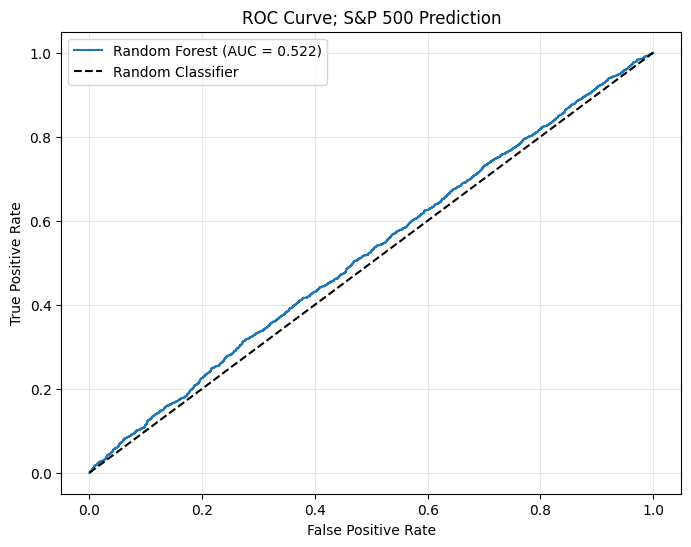

In [14]:
fpr, tpr, thresholds = roc_curve(predictions["Target"], predictions["Probabilities"])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve; S&P 500 Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()